In [1]:
from pathlib import Path
from collections import defaultdict

DATASET_PATH = Path(r"D:\Dataset_BUSI_with_GT")

for category in ["benign", "malignant", "normal"]:
    folder = DATASET_PATH / category

    images = {
        f.stem: f
        for f in folder.glob("*.png")
        if "_mask" not in f.stem
    }

    masks = [
        f for f in folder.glob("*.png")
        if "_mask" in f.stem
    ]

    mask_count = defaultdict(int)

    for mask in masks:
        # Remove the "_mask..." portion
        base_name = mask.stem.split("_mask")[0]
        mask_count[base_name] += 1

    multiple_masks = {
        name: count
        for name, count in mask_count.items()
        if count > 1
    }

    print("\n" + "=" * 50)
    print(category.upper())
    print("=" * 50)

    print("Images:", len(images))
    print("Masks :", len(masks))

    print("\nImages with multiple masks:")

    if multiple_masks:
        for name, count in multiple_masks.items():
            print(f"{name} → {count} masks")
    else:
        print("None")


BENIGN
Images: 437
Masks : 454

Images with multiple masks:
benign (100) → 2 masks
benign (163) → 2 masks
benign (173) → 2 masks
benign (181) → 2 masks
benign (195) → 3 masks
benign (25) → 2 masks
benign (315) → 2 masks
benign (346) → 2 masks
benign (4) → 2 masks
benign (424) → 2 masks
benign (54) → 2 masks
benign (58) → 2 masks
benign (83) → 2 masks
benign (92) → 2 masks
benign (93) → 2 masks
benign (98) → 2 masks

MALIGNANT
Images: 210
Masks : 211

Images with multiple masks:
malignant (53) → 2 masks

NORMAL
Images: 133
Masks : 133

Images with multiple masks:
None


In [3]:
from pathlib import Path
from collections import defaultdict

DATASET_PATH = Path(r"D:\Dataset_BUSI_with_GT")

for category in ["normal"]:

    folder = DATASET_PATH / category

    images = [
        f for f in folder.glob("*.png")
        if "_mask" not in f.stem
    ]

    masks = [
        f for f in folder.glob("*.png")
        if "_mask" in f.stem
    ]

    mask_dict = defaultdict(list)

    for mask in masks:
        base_name = mask.stem.split("_mask")[0]
        mask_dict[base_name].append(mask)

    missing_masks = []
    multiple_masks = {}

    for image in images:
        if image.stem not in mask_dict:
            missing_masks.append(image.name)

        elif len(mask_dict[image.stem]) > 1:
            multiple_masks[image.stem] = [
                m.name for m in mask_dict[image.stem]
            ]

    print("\n" + "="*60)
    print(category.upper())
    print("="*60)

    print("Images:", len(images))
    print("Masks :", len(masks))

    print("\nImages WITHOUT mask:", len(missing_masks))

    if missing_masks:
        print(missing_masks)

    print("\nImages with MULTIPLE masks:", len(multiple_masks))

    for image, masks_list in multiple_masks.items():
        print(image)
        for m in masks_list:
            print("   └──", m)


NORMAL
Images: 133
Masks : 133

Images WITHOUT mask: 0

Images with MULTIPLE masks: 0


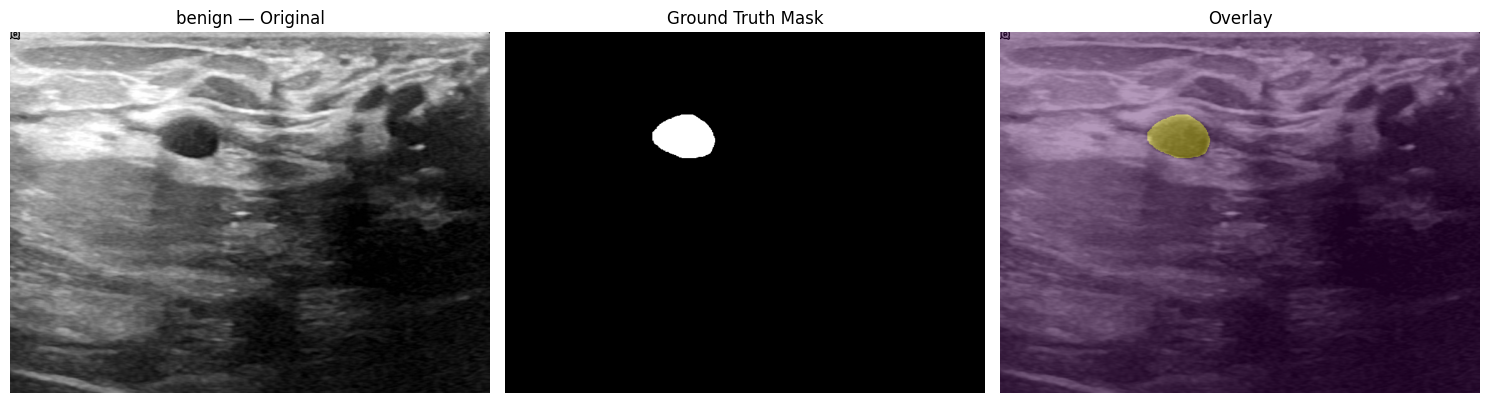

Image: benign (369).png
Number of masks: 1


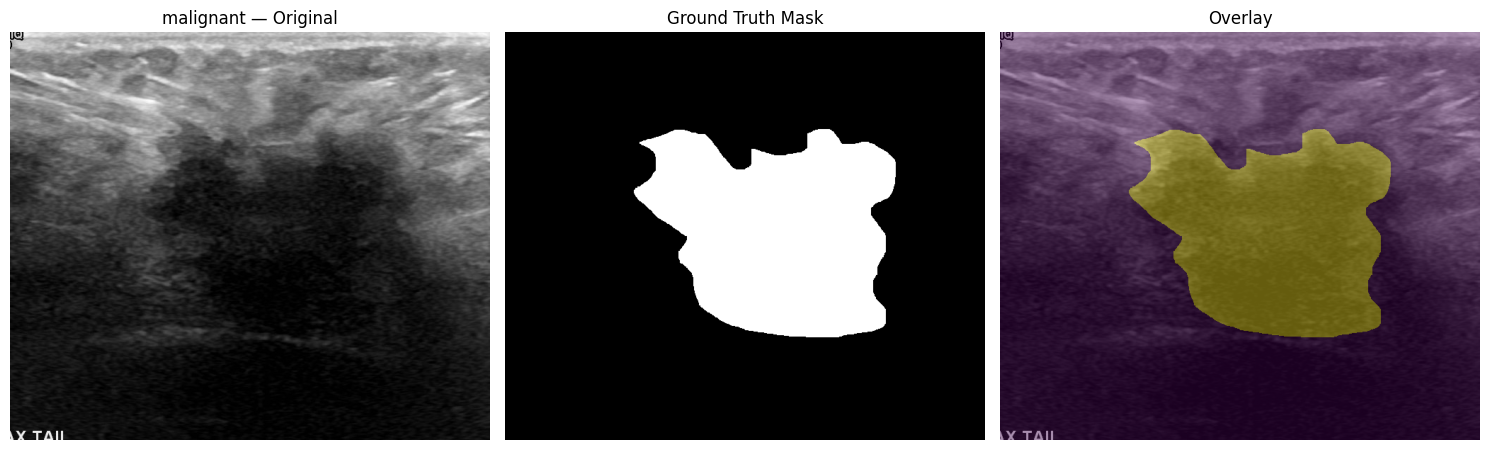

Image: malignant (201).png
Number of masks: 1


In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def get_masks(image_path):
    folder = image_path.parent
    base = image_path.stem

    masks = list(folder.glob(f"{base}_mask*.png"))
    return masks


# Pick random benign and malignant images
for category in ["benign", "malignant"]:

    folder = DATASET_PATH / category

    images = [
        f for f in folder.glob("*.png")
        if "_mask" not in f.stem
    ]

    image_path = random.choice(images)

    image = Image.open(image_path).convert("L")
    masks = get_masks(image_path)

    # Combine all masks
    combined_mask = None

    for mask_path in masks:
        mask = Image.open(mask_path).convert("L")

        if combined_mask is None:
            combined_mask = mask
        else:
            import numpy as np

            combined_mask = Image.fromarray(
                np.maximum(
                    np.array(combined_mask),
                    np.array(mask)
                )
            )

    import numpy as np

    image_np = np.array(image)
    mask_np = np.array(combined_mask)

    # Binary mask
    mask_binary = mask_np > 0

    # Overlay
    overlay = image_np.copy()

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_np, cmap="gray")
    axes[0].set_title(f"{category} — Original")

    axes[1].imshow(mask_binary, cmap="gray")
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(image_np, cmap="gray")
    axes[2].imshow(mask_binary, alpha=0.4)
    axes[2].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Image:", image_path.name)
    print("Number of masks:", len(masks))
    

In [5]:
multi_mask_cases = []

for category in ["benign", "malignant"]:

    folder = DATASET_PATH / category

    images = [
        f for f in folder.glob("*.png")
        if "_mask" not in f.stem
    ]

    for image_path in images:

        masks = get_masks(image_path)

        if len(masks) > 1:
            multi_mask_cases.append(
                (category, image_path, masks)
            )

print("Total multi-mask cases:", len(multi_mask_cases))


Total multi-mask cases: 17


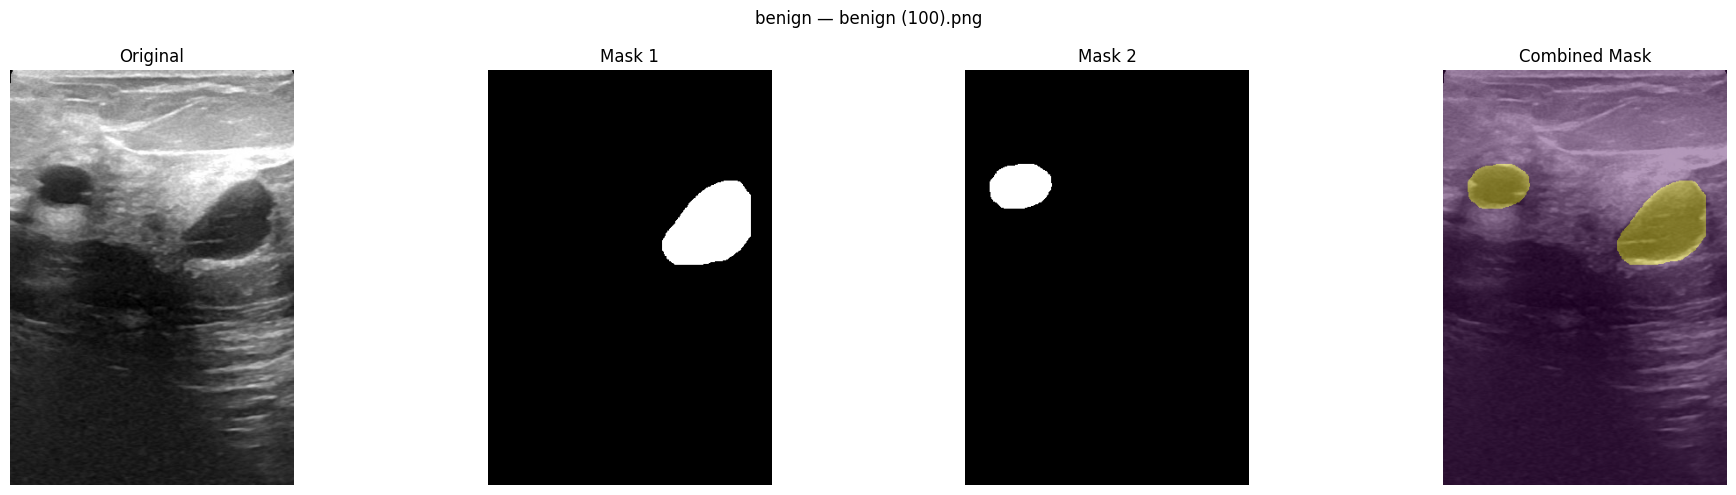

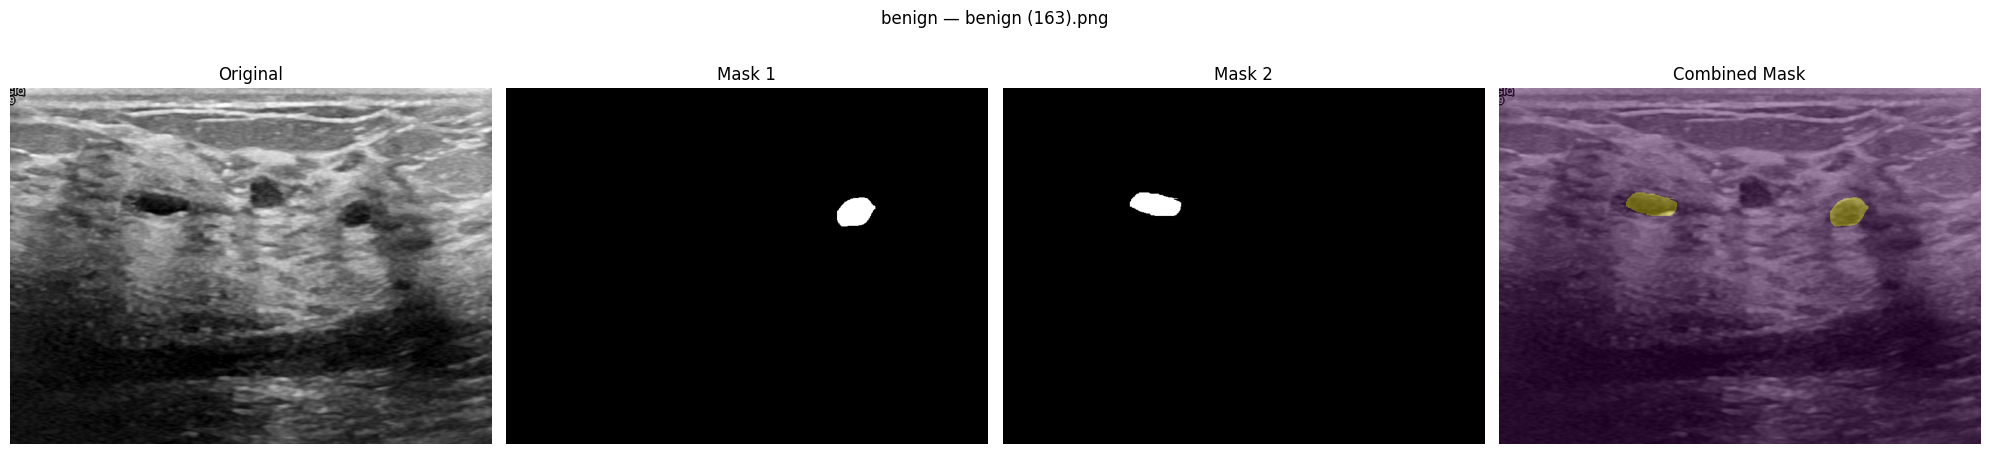

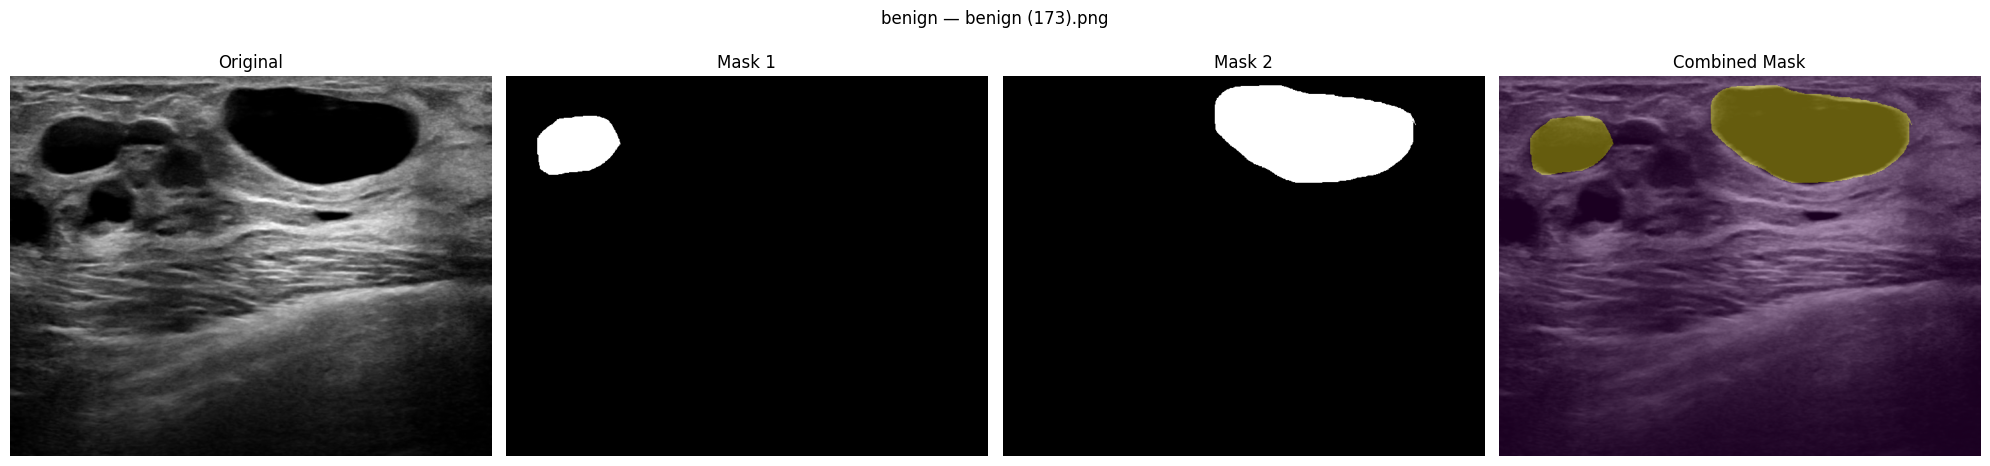

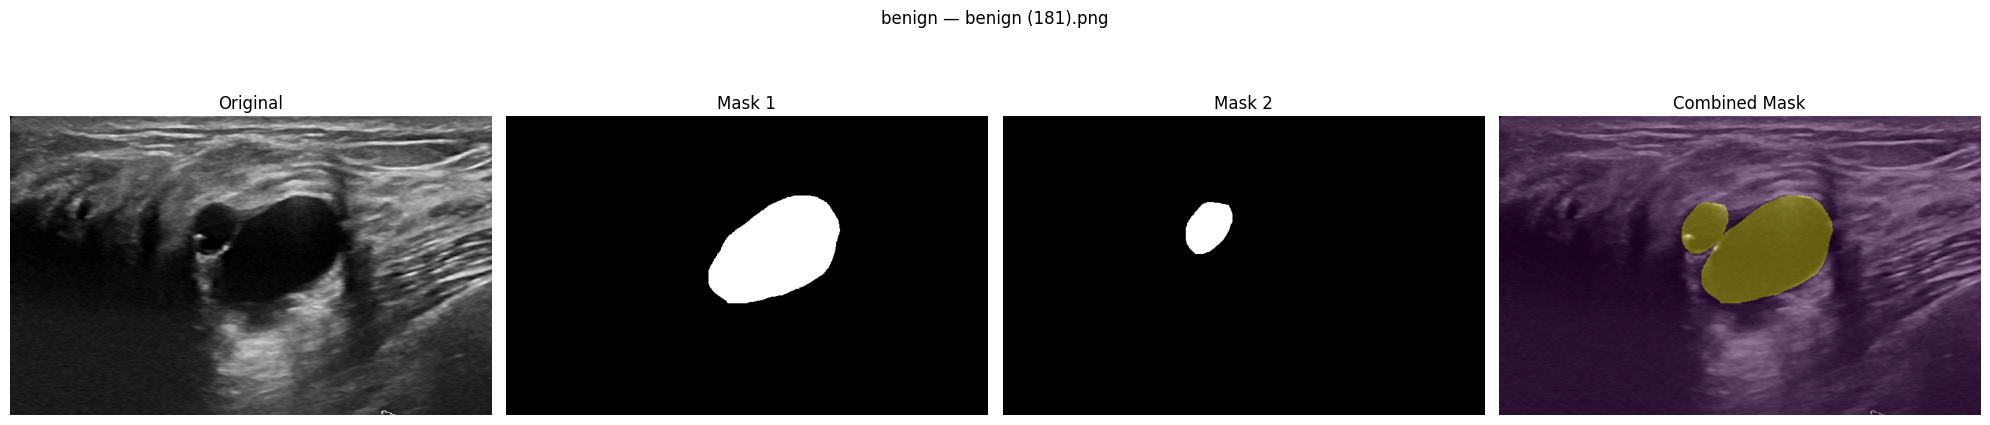

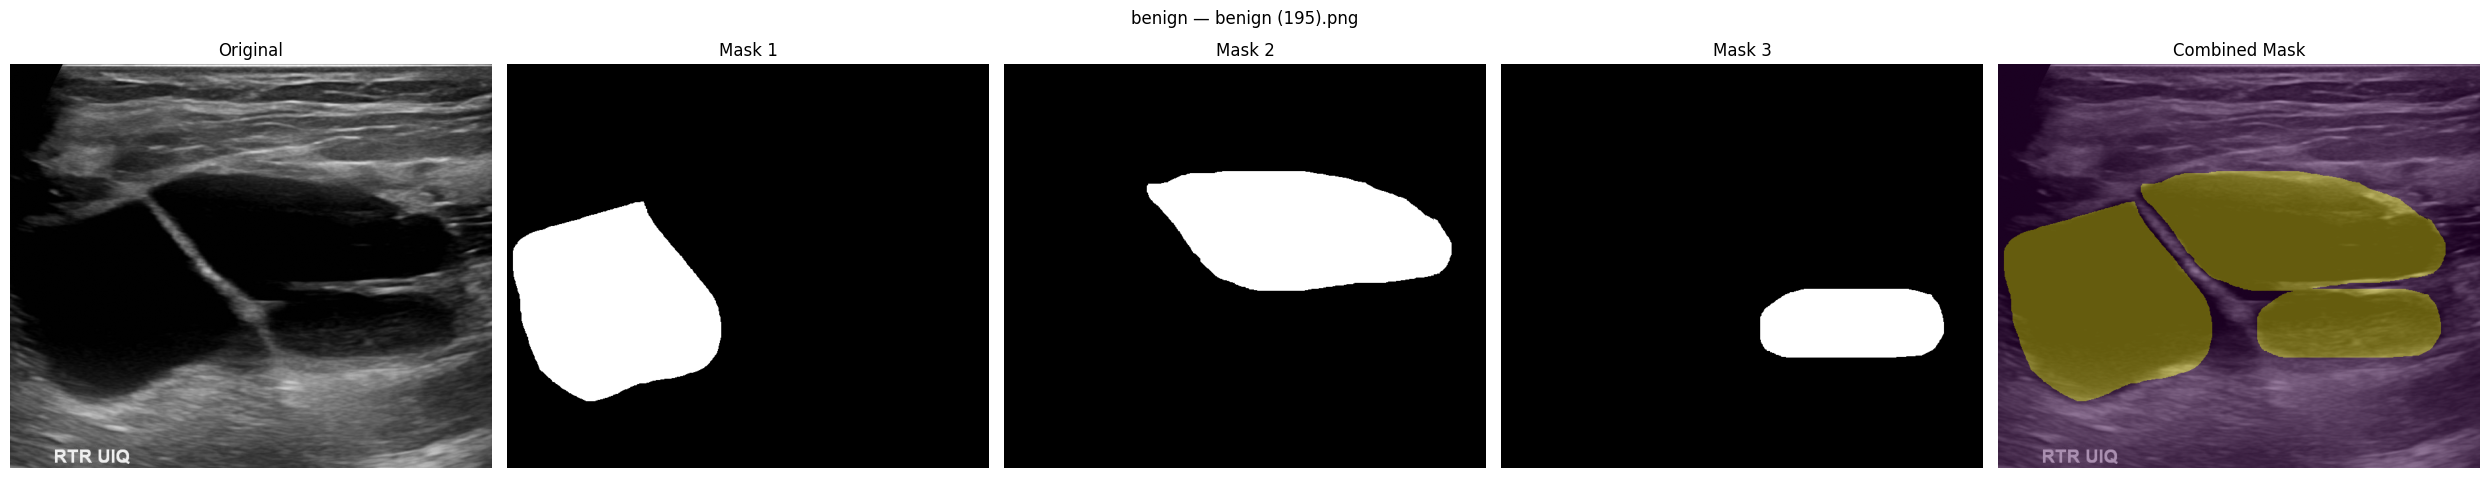

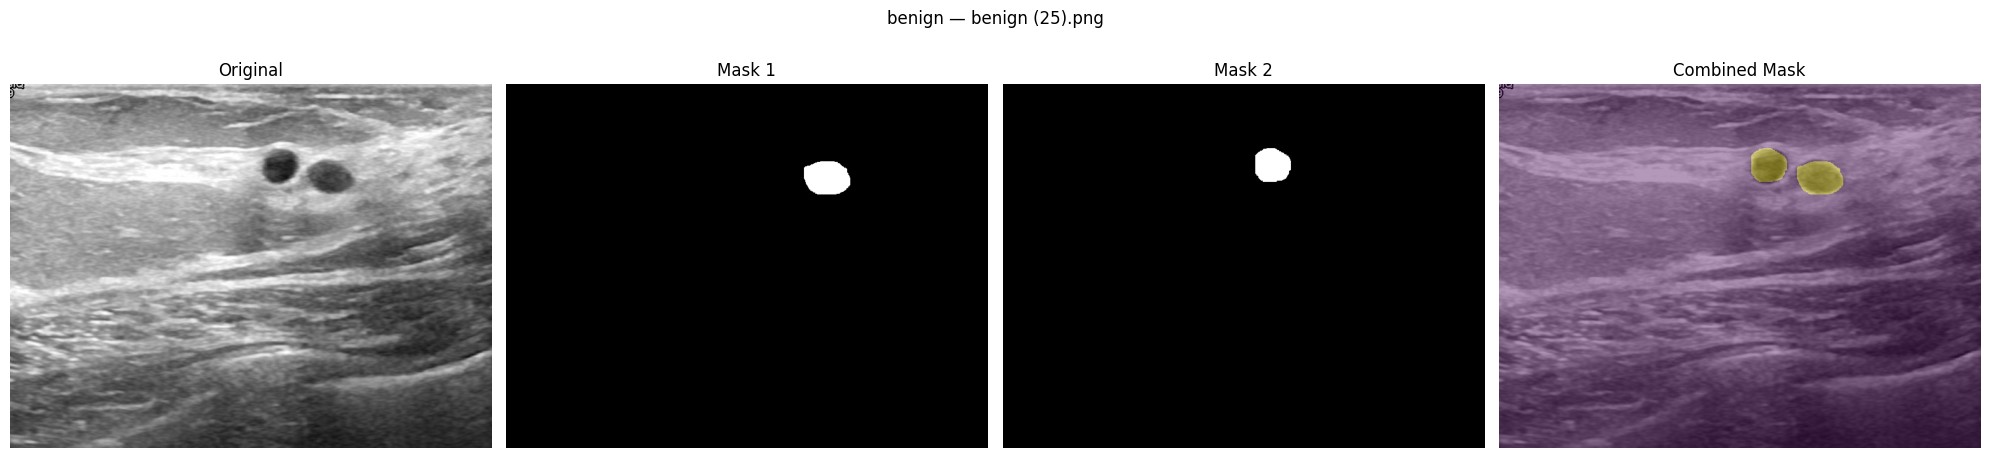

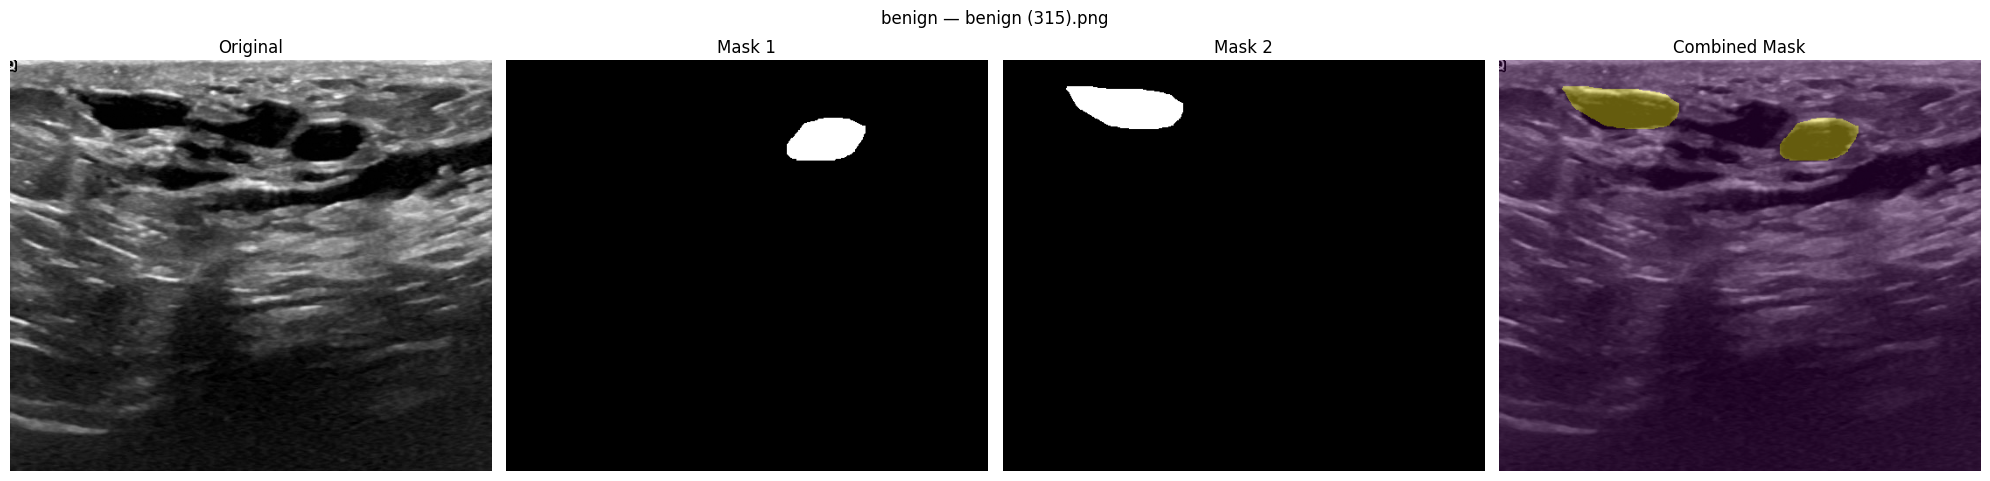

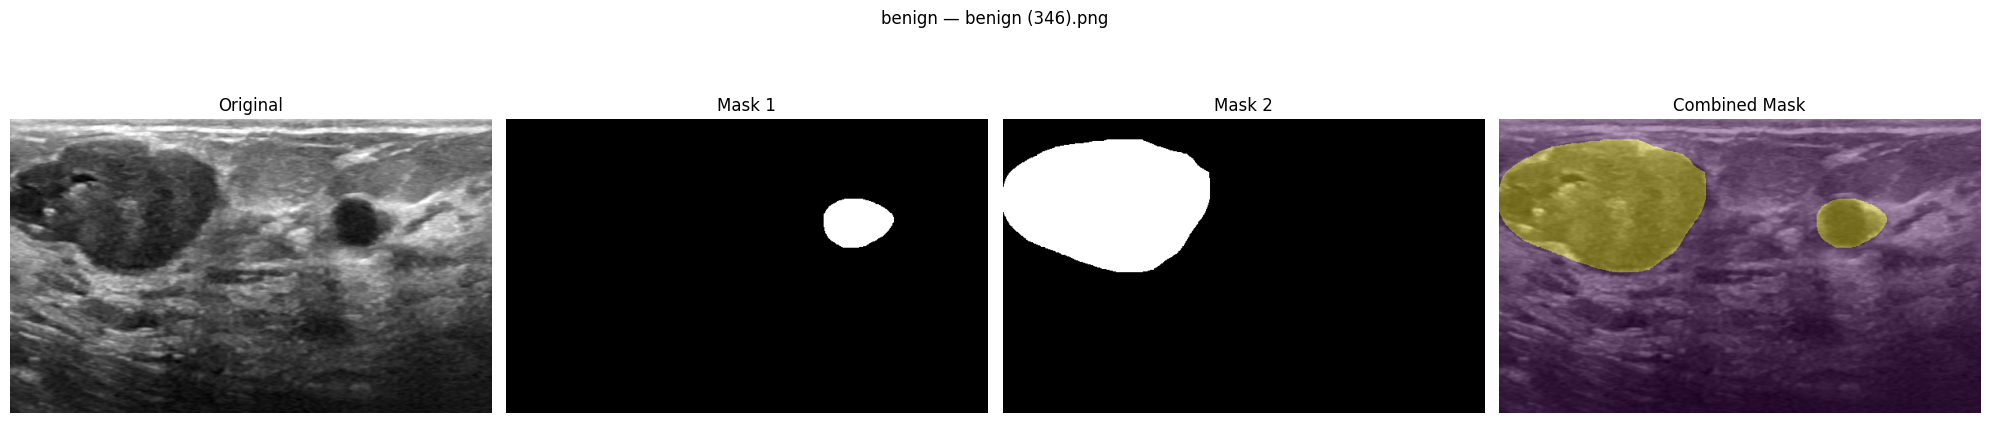

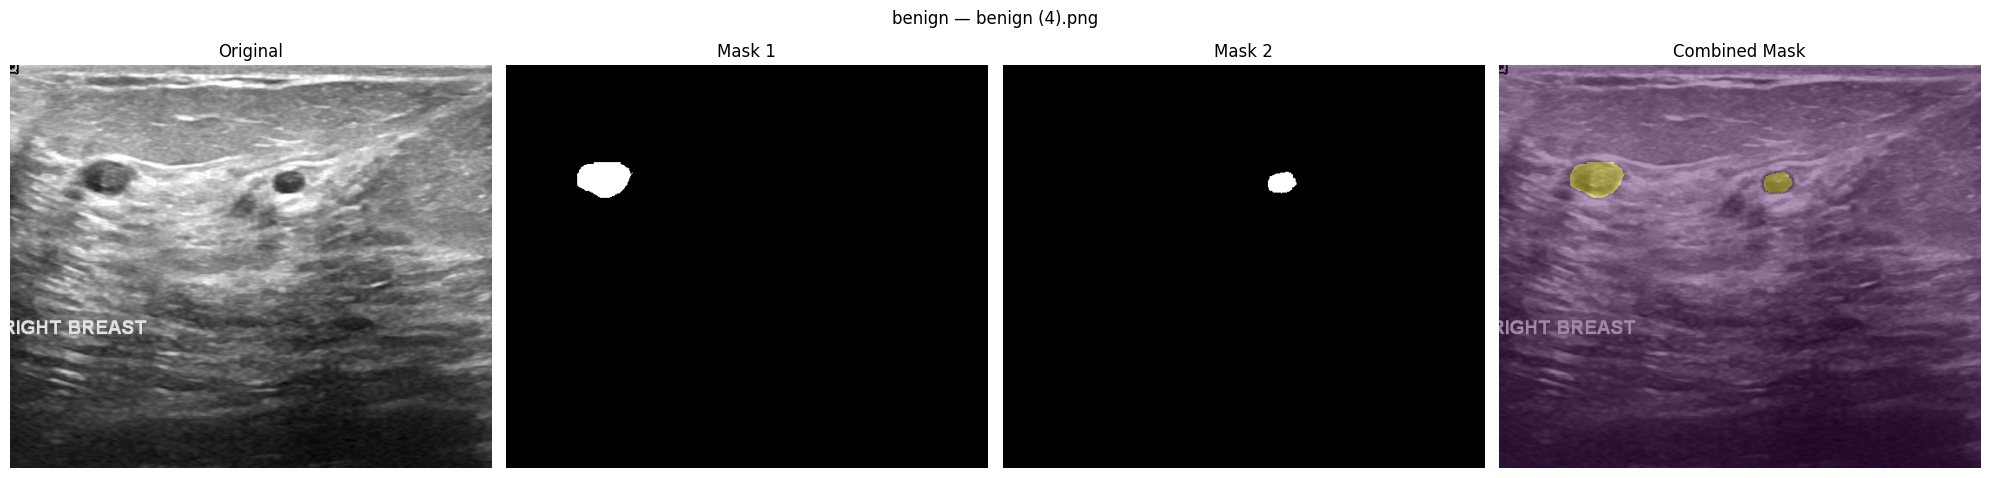

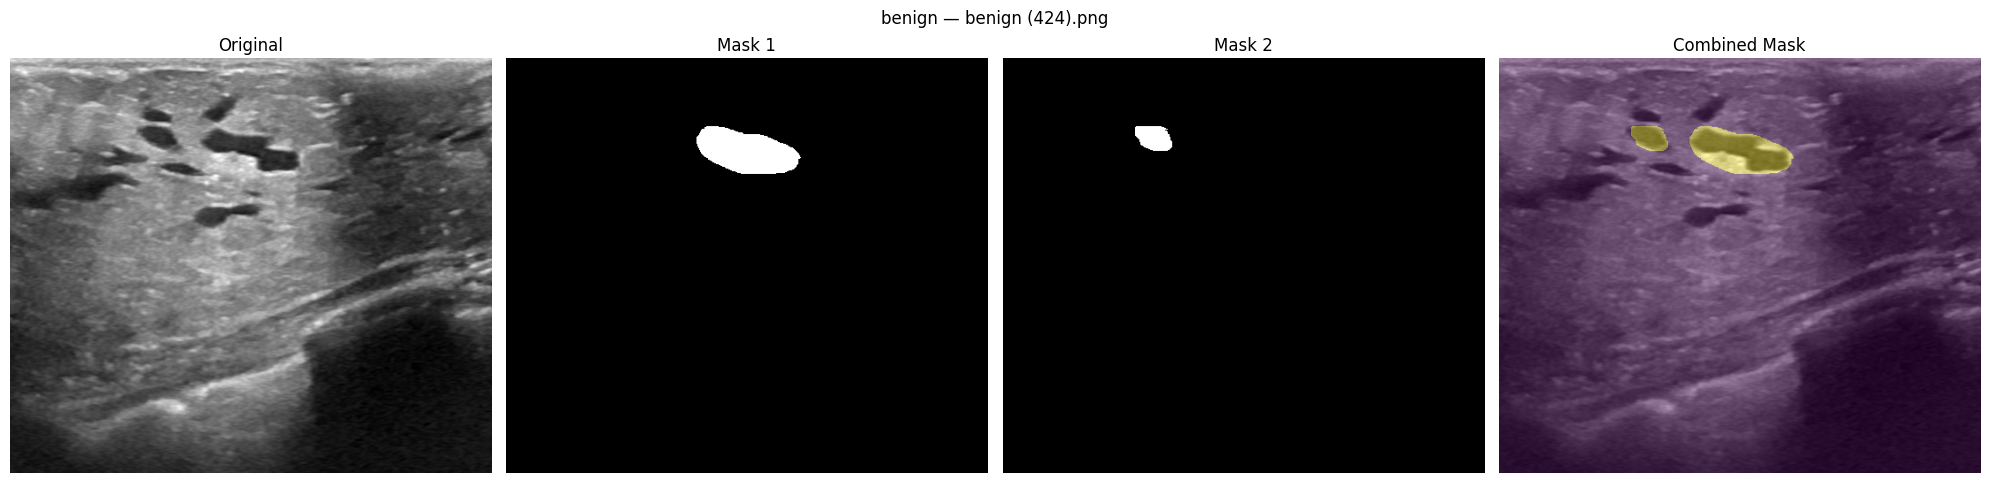

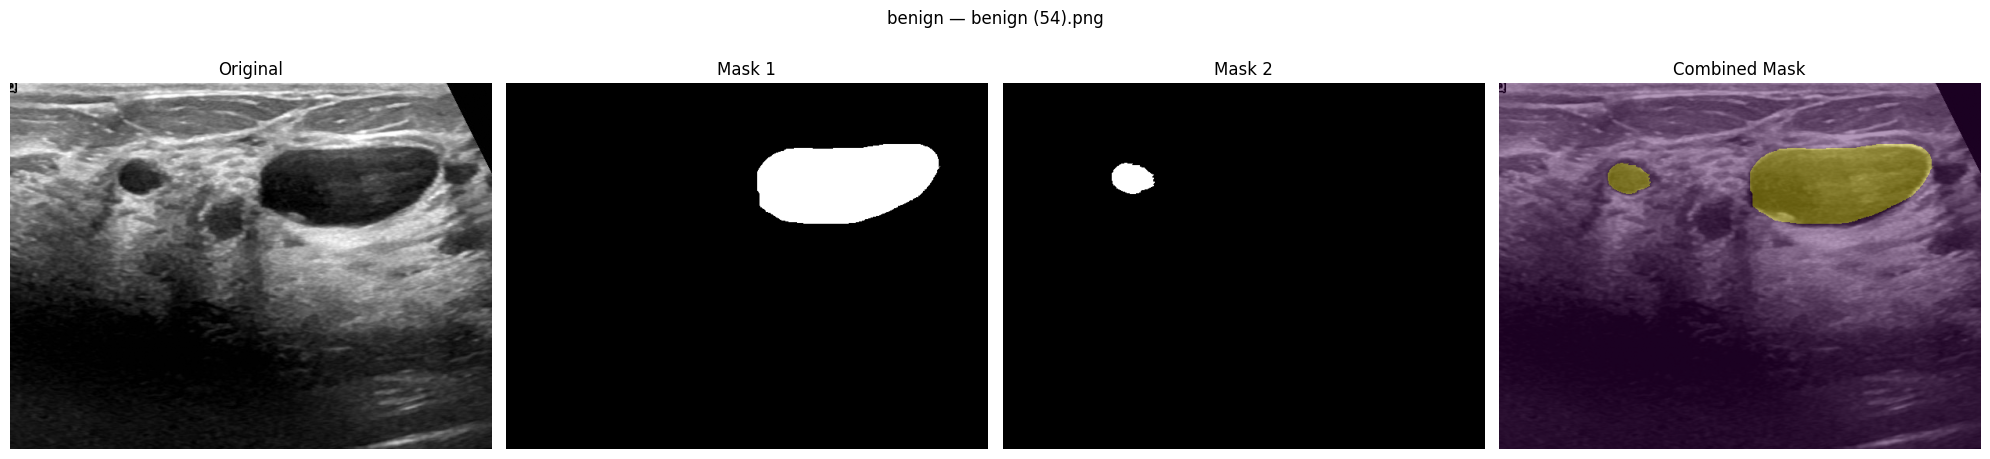

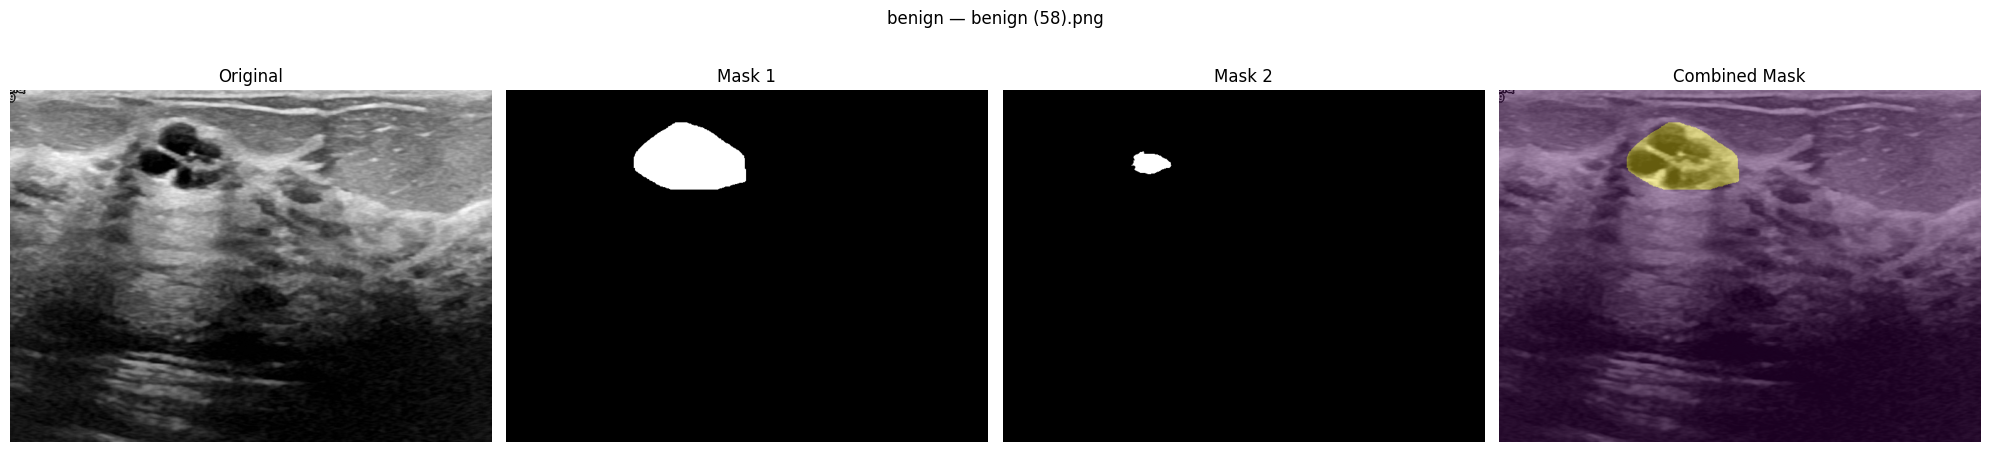

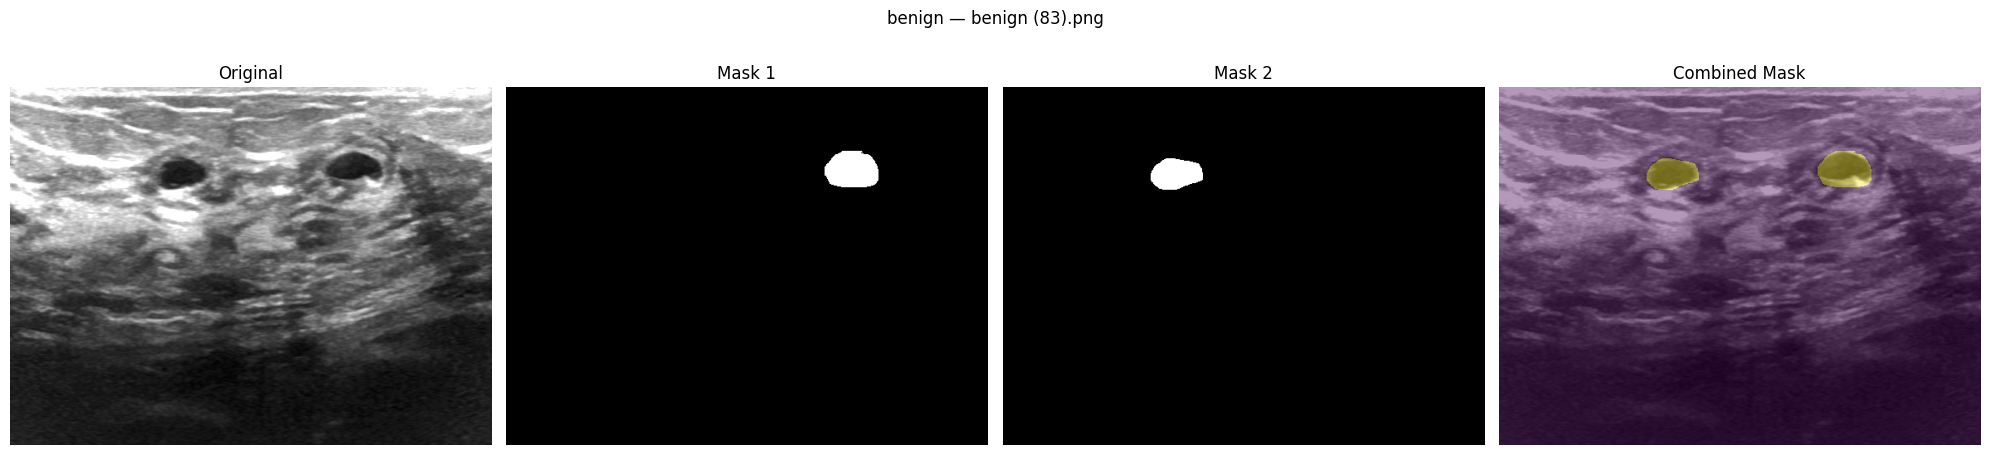

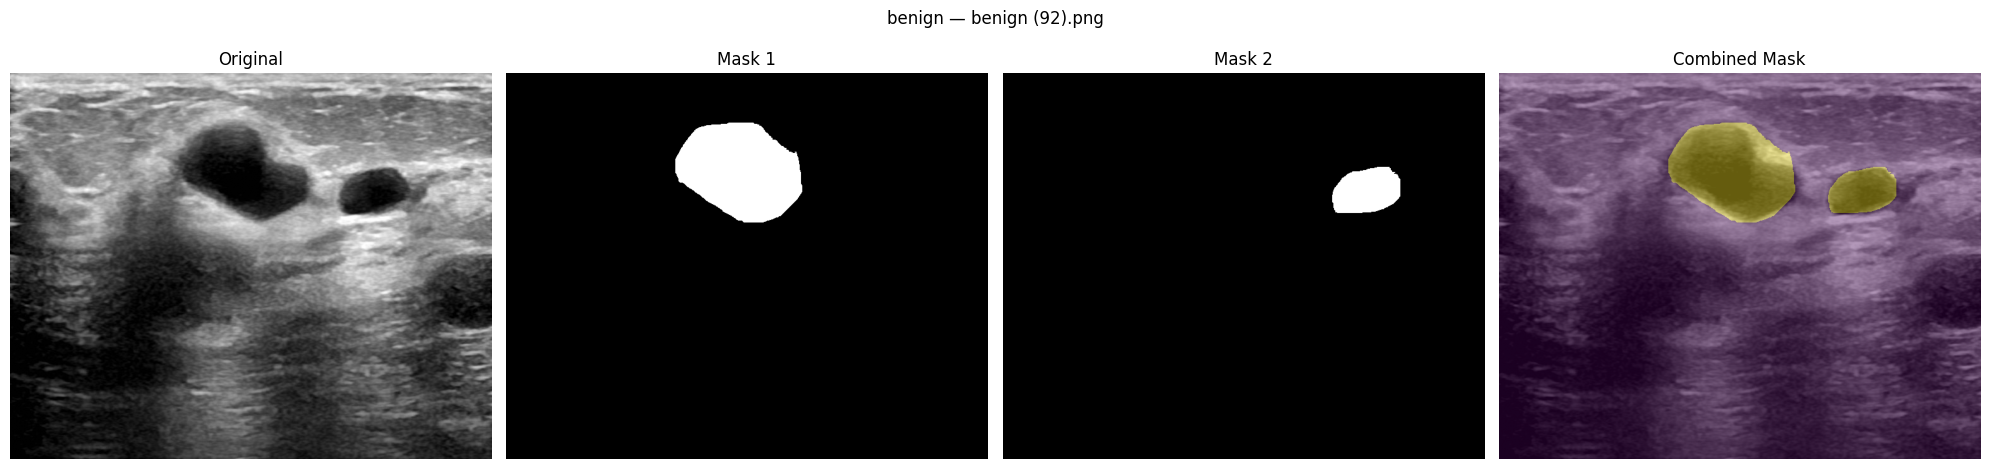

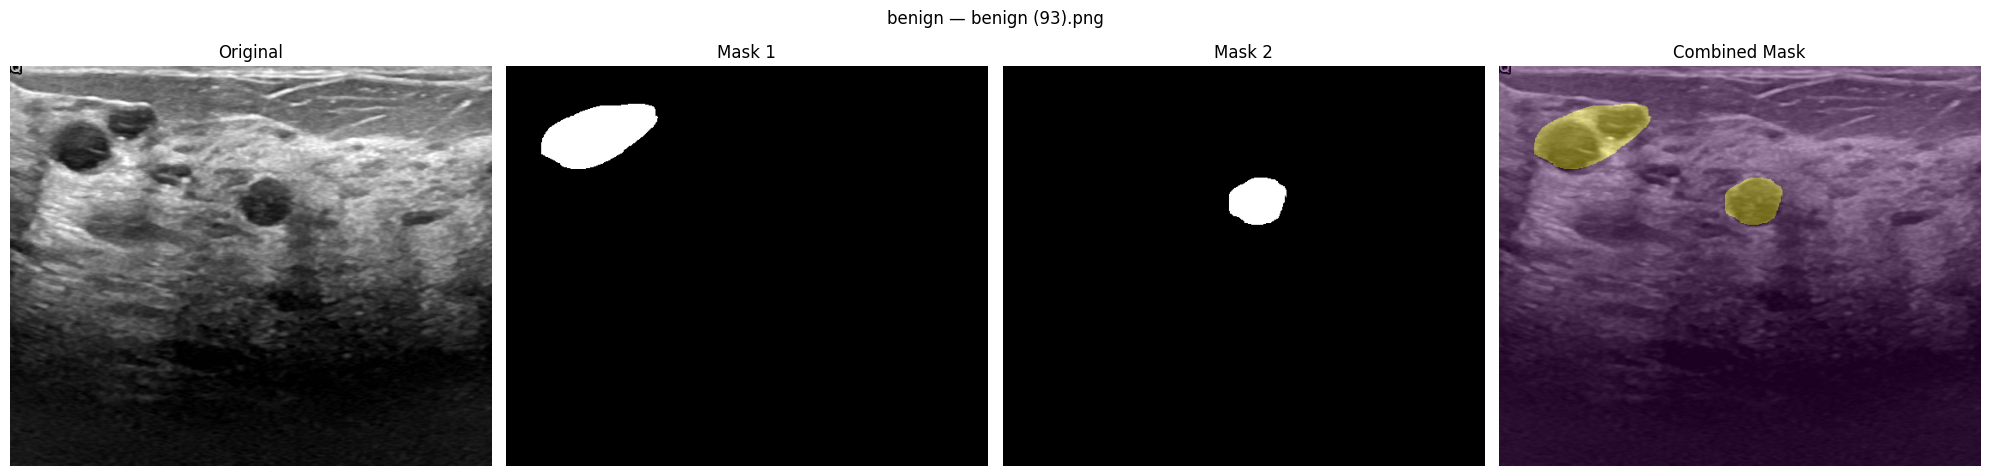

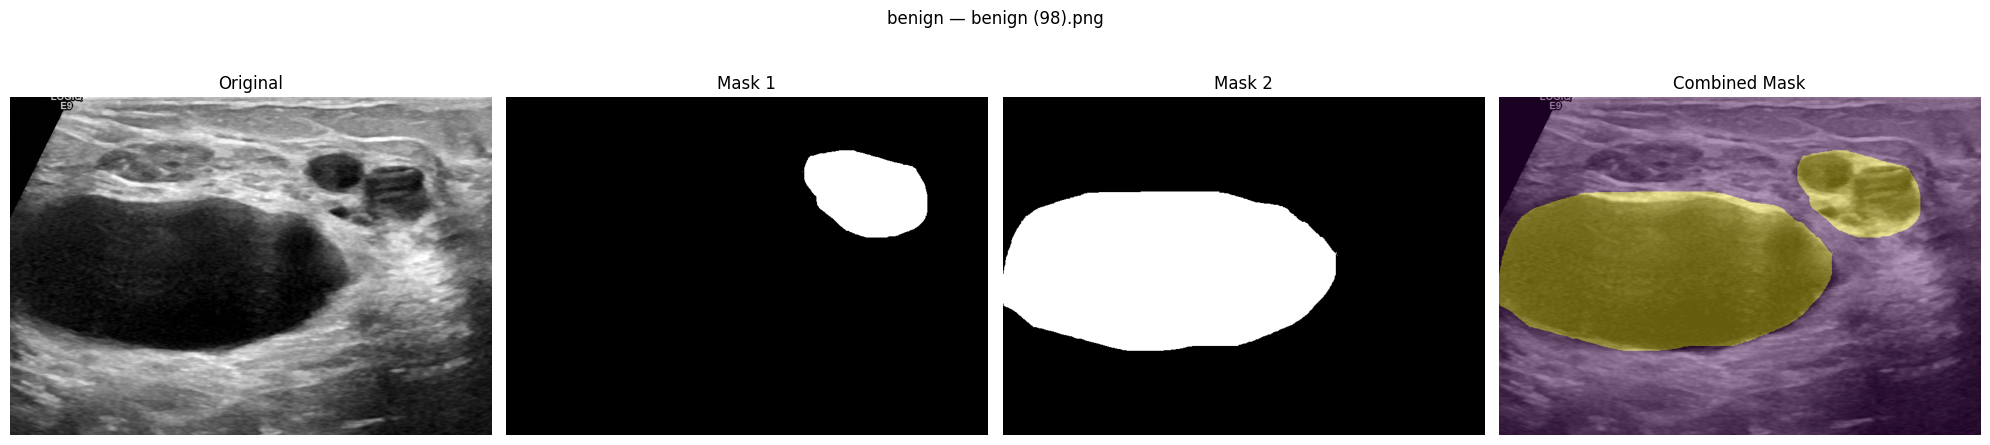

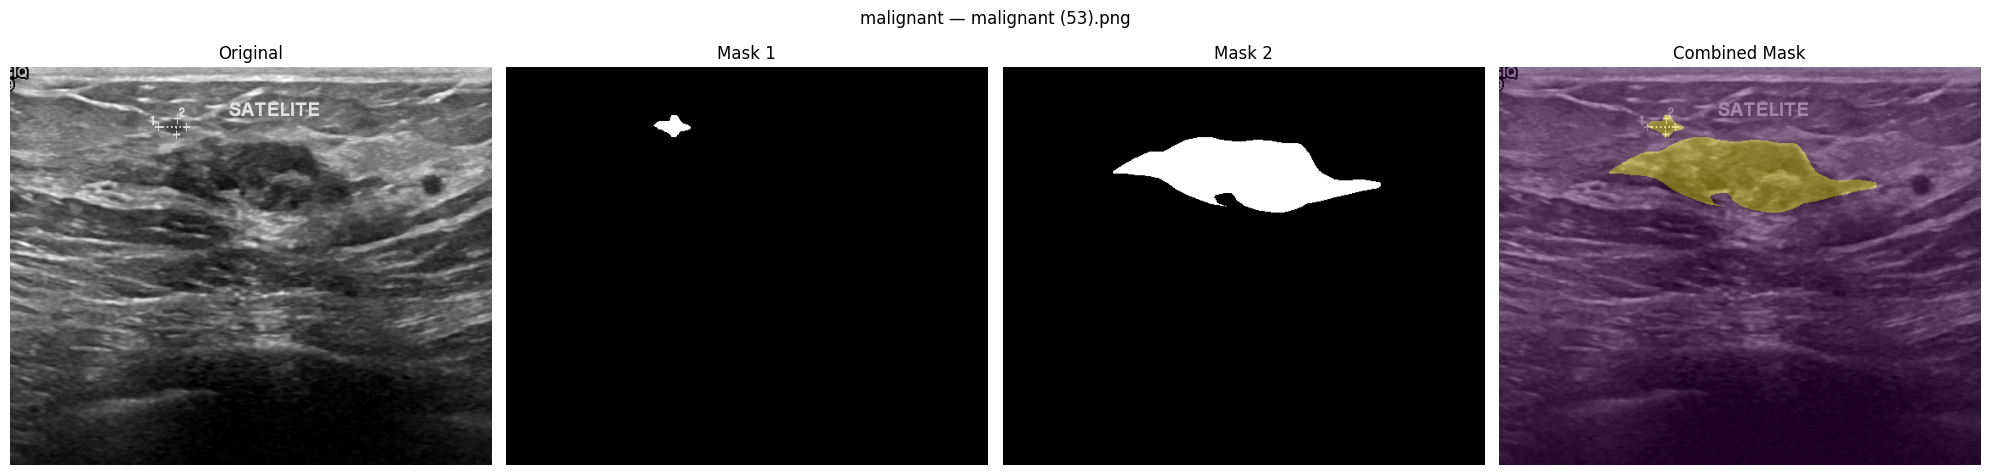

In [6]:
for category, image_path, masks in multi_mask_cases:

    image = Image.open(image_path).convert("L")

    import numpy as np

    image_np = np.array(image)

    fig, axes = plt.subplots(
        1,
        len(masks) + 2,
        figsize=(5 * (len(masks) + 2), 5)
    )

    axes[0].imshow(image_np, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    combined = np.zeros(image_np.shape, dtype=np.uint8)

    for i, mask_path in enumerate(masks):

        mask = np.array(
            Image.open(mask_path).convert("L")
        )

        mask_binary = mask > 0

        combined = np.maximum(
            combined,
            mask_binary.astype(np.uint8)
        )

        axes[i + 1].imshow(mask_binary, cmap="gray")
        axes[i + 1].set_title(f"Mask {i+1}")
        axes[i + 1].axis("off")

    axes[-1].imshow(image_np, cmap="gray")
    axes[-1].imshow(combined, alpha=0.4)
    axes[-1].set_title("Combined Mask")
    axes[-1].axis("off")

    plt.suptitle(f"{category} — {image_path.name}")

    plt.tight_layout()
    plt.show()

In [7]:
import hashlib

def file_hash(path):
    h = hashlib.md5()

    with open(path, "rb") as f:
        h.update(f.read())

    return h.hexdigest()


hashes = {}

for category in ["benign", "malignant", "normal"]:

    folder = DATASET_PATH / category

    for image_path in folder.glob("*.png"):

        if "_mask" in image_path.stem:
            continue

        h = file_hash(image_path)

        if h not in hashes:
            hashes[h] = []

        hashes[h].append(
            (category, image_path.name)
        )


duplicates = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

print("Total duplicate groups:", len(duplicates))

for h, files in duplicates.items():
    print("\nDuplicate:")
    for category, filename in files:
        print(f"  {category}/{filename}")

Total duplicate groups: 1

Duplicate:
  benign/benign (433).png
  malignant/malignant (145).png
